In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.linear_model import LinearRegression

In [2]:
population_df = pd.read_csv("../dataset/cleaned_population_dataset.csv")
params_df = pd.read_csv("../dataset/cleaned_general_parameters_dataset.csv")
mortality_df = pd.read_csv("../dataset/cleaned_mortality_parameters_dataset.csv")

In [3]:
age_groups = ["0", "1-14", "15-64", "65-89", "90+"]
sexes = ["Male", "Female"]

age_widths = {
    "0": 1,
    "1-14": 14,
    "15-64": 50,
    "65-89": 25,
    "90+": None
}

stocks = [(age, sex) for age in age_groups for sex in sexes]
stock_index = {stock: i for i, stock in enumerate(stocks)}
print(stocks)

[('0', 'Male'), ('0', 'Female'), ('1-14', 'Male'), ('1-14', 'Female'), ('15-64', 'Male'), ('15-64', 'Female'), ('65-89', 'Male'), ('65-89', 'Female'), ('90+', 'Male'), ('90+', 'Female')]


In [4]:
future_start_year = 2020
future_end_year = 2030

future_years = np.arange(future_start_year, future_end_year + 1)

def extrapolate_column_linear(df, year_col, value_col, future_years):
    """
    Fits a linear trend on historical values and predicts future values.
    """
    historical = df[[year_col, value_col]].dropna().copy()

    X = historical[[year_col]].values
    y = historical[value_col].values

    model = LinearRegression()
    model.fit(X, y)

    future_X = future_years.reshape(-1, 1)
    future_values = model.predict(future_X)

    return future_values


future_total_fertility_rate = extrapolate_column_linear(
    params_df,
    "Year",
    "Total fertility rate",
    future_years
)

future_net_migration_rate = extrapolate_column_linear(
    params_df,
    "Year",
    "Net Migration Rate",
    future_years
)

future_params_df = pd.DataFrame({
    "Year": future_years,
    "Total fertility rate": future_total_fertility_rate,
    "Net Migration Rate": future_net_migration_rate,
    "p_male": params_df["p_male"].mean(),
    "p_female": params_df["p_female"].mean()
})

future_params_df

,Year,Total fertility rate,Net Migration Rate,p_male,p_female
0,2020,1.510578,0.006745,0.5134,0.4866
1,2021,1.518425,0.006896,0.5134,0.4866
2,2022,1.526272,0.007046,0.5134,0.4866
3,2023,1.534119,0.007196,0.5134,0.4866
4,2024,1.541966,0.007346,0.5134,0.4866
5,2025,1.549813,0.007496,0.5134,0.4866
6,2026,1.557660,0.007647,0.5134,0.4866
7,2027,1.565508,0.007797,0.5134,0.4866
8,2028,1.573355,0.007947,0.5134,0.4866
9,2029,1.581202,0.008097,0.5134,0.4866


In [5]:
future_mortality_rows = []

for age in mortality_df["Age"].unique():
    for sex in mortality_df["Sex"].unique():

        subset = mortality_df[
            (mortality_df["Age"] == age) &
            (mortality_df["Sex"] == sex)
        ].copy()

        if subset.empty:
            continue

        future_values = extrapolate_column_linear(
            subset,
            "Year",
            "Mortality Rate",
            future_years
        )

        # Mortality cannot be negative
        future_values = np.clip(future_values, a_min=0, a_max=None)

        for year, value in zip(future_years, future_values):
            future_mortality_rows.append({
                "Year": year,
                "Age": age,
                "Sex": sex,
                "Mortality Rate": value
            })

future_mortality_df = pd.DataFrame(future_mortality_rows)

future_mortality_df.head(20)

,Year,Age,Sex,Mortality Rate
0,2020,0,Female,0.002443
1,2021,0,Female,0.002364
2,2022,0,Female,0.002285
3,2023,0,Female,0.002206
4,2024,0,Female,0.002127
5,2025,0,Female,0.002048
6,2026,0,Female,0.001968
7,2027,0,Female,0.001889
8,2028,0,Female,0.001810
9,2029,0,Female,0.001731


In [6]:
params_df_extended = pd.concat(
    [params_df, future_params_df],
    ignore_index=True
)

mortality_df_extended = pd.concat(
    [mortality_df, future_mortality_df],
    ignore_index=True
)

print(params_df_extended.tail(15))
print(mortality_df_extended.tail(20))


    Year  Net Migration Rate  Total fertility rate  p_male  p_female
16  2016            0.007551              1.531366  0.5134    0.4866
17  2017            0.005169              1.520947  0.5134    0.4866
18  2018            0.003992              1.478848  0.5134    0.4866
19  2019            0.004627              1.464192  0.5134    0.4866
20  2020            0.006745              1.510578  0.5134    0.4866
21  2021            0.006896              1.518425  0.5134    0.4866
22  2022            0.007046              1.526272  0.5134    0.4866
23  2023            0.007196              1.534119  0.5134    0.4866
24  2024            0.007346              1.541966  0.5134    0.4866
25  2025            0.007496              1.549813  0.5134    0.4866
26  2026            0.007647              1.557660  0.5134    0.4866
27  2027            0.007797              1.565508  0.5134    0.4866
28  2028            0.007947              1.573355  0.5134    0.4866
29  2029            0.008097      

In [7]:
print("Minimum mortality rate:", future_mortality_df["Mortality Rate"].min())
print("Maximum mortality rate:", future_mortality_df["Mortality Rate"].max())

future_mortality_df[
    future_mortality_df["Mortality Rate"] < 0
]

Minimum mortality rate: 4.9402949874686325e-05
Maximum mortality rate: 0.37211590233333336


,Year,Age,Sex,Mortality Rate


In [8]:
for age in future_mortality_df["Age"].unique():
    for sex in future_mortality_df["Sex"].unique():
        subset = future_mortality_df[
            (future_mortality_df["Age"] == age) &
            (future_mortality_df["Sex"] == sex)
        ]

        print(age, sex)
        print(subset[["Year", "Mortality Rate"]])
        print()

0 Female
    Year  Mortality Rate
0   2020        0.002443
1   2021        0.002364
2   2022        0.002285
3   2023        0.002206
4   2024        0.002127
5   2025        0.002048
6   2026        0.001968
7   2027        0.001889
8   2028        0.001810
9   2029        0.001731
10  2030        0.001652

0 Male
    Year  Mortality Rate
11  2020        0.002789
12  2021        0.002666
13  2022        0.002542
14  2023        0.002419
15  2024        0.002295
16  2025        0.002172
17  2026        0.002048
18  2027        0.001925
19  2028        0.001801
20  2029        0.001677
21  2030        0.001554

1-14 Female
    Year  Mortality Rate
22  2020        0.000081
23  2021        0.000078
24  2022        0.000075
25  2023        0.000072
26  2024        0.000068
27  2025        0.000065
28  2026        0.000062
29  2027        0.000059
30  2028        0.000056
31  2029        0.000053
32  2030        0.000049

1-14 Male
    Year  Mortality Rate
33  2020        0.000107
34  2021 

In [9]:
future_params_df.to_csv(
    "../dataset/extrapolated_general_parameters_2020_2030.csv",
    index=False
)

future_mortality_df.to_csv(
    "../dataset/extrapolated_mortality_parameters_2020_2030.csv",
    index=False
)

In [10]:
# Blue color palette
blue_dark = "#005F99"
blue_medium = "#2A9FD6"
blue_light = "#8ECAE6"
blue_teal = "#4D96A9"
blue_navy = "#023047"
blue_pale = "#BDE0FE"
blue_gray = "#6C8EA4"

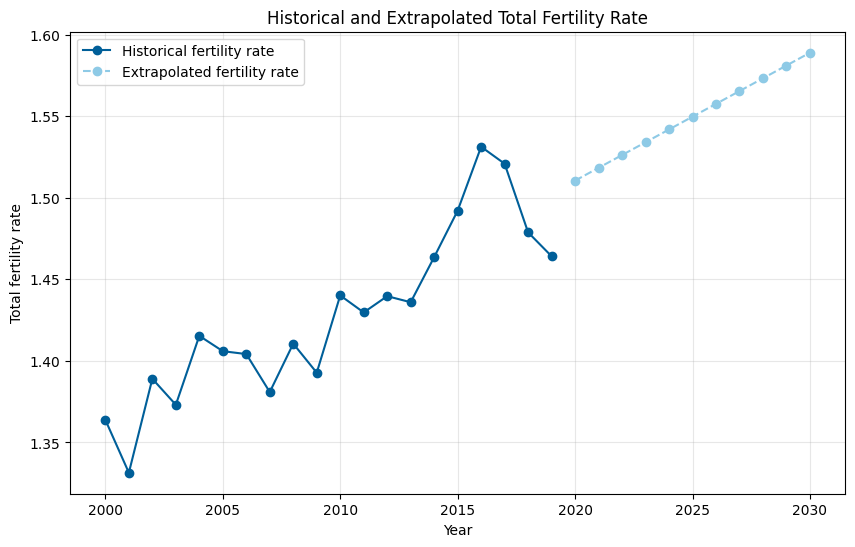

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    params_df["Year"],
    params_df["Total fertility rate"],
    marker="o",
    color=blue_dark,
    label="Historical fertility rate"
)

plt.plot(
    future_params_df["Year"],
    future_params_df["Total fertility rate"],
    marker="o",
    linestyle="--",
    color=blue_light,
    label="Extrapolated fertility rate"
)

plt.xlabel("Year")
plt.ylabel("Total fertility rate")
plt.title("Historical and Extrapolated Total Fertility Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

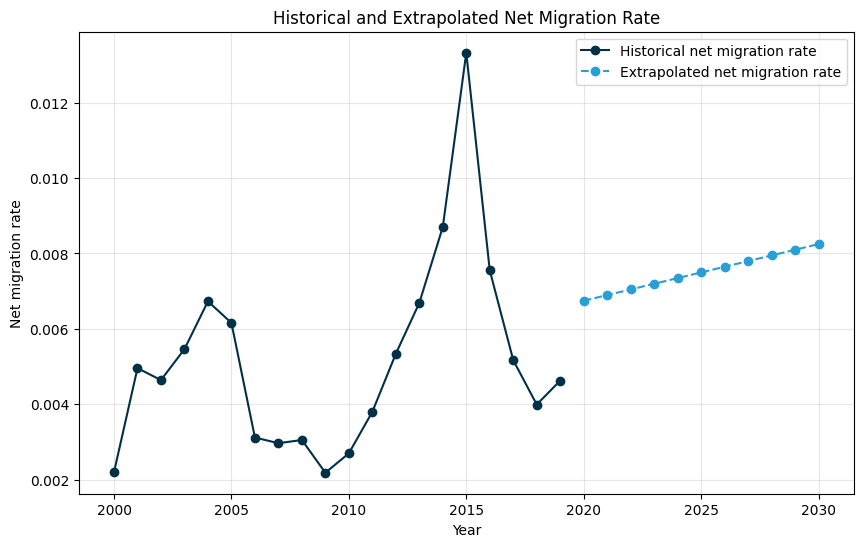

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(
    params_df["Year"],
    params_df["Net Migration Rate"],
    marker="o",
    color=blue_navy,
    label="Historical net migration rate"
)

plt.plot(
    future_params_df["Year"],
    future_params_df["Net Migration Rate"],
    marker="o",
    linestyle="--",
    color=blue_medium,
    label="Extrapolated net migration rate"
)

plt.xlabel("Year")
plt.ylabel("Net migration rate")
plt.title("Historical and Extrapolated Net Migration Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

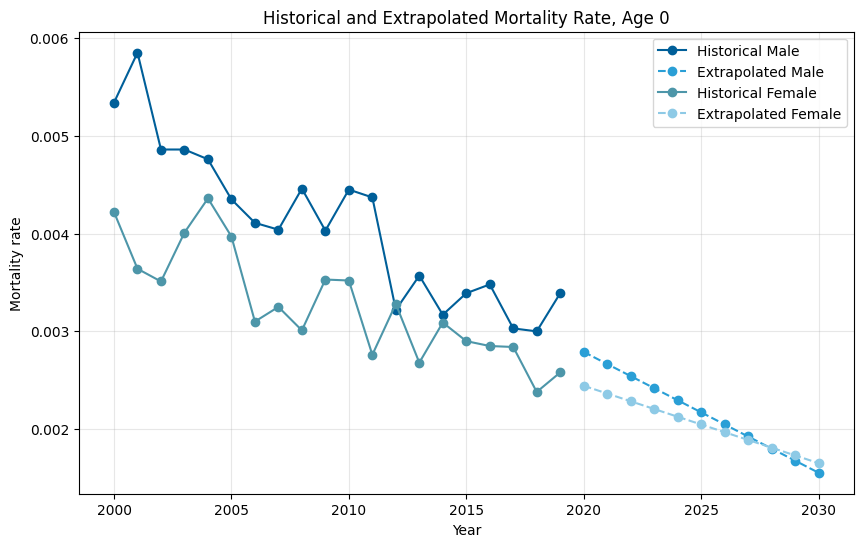

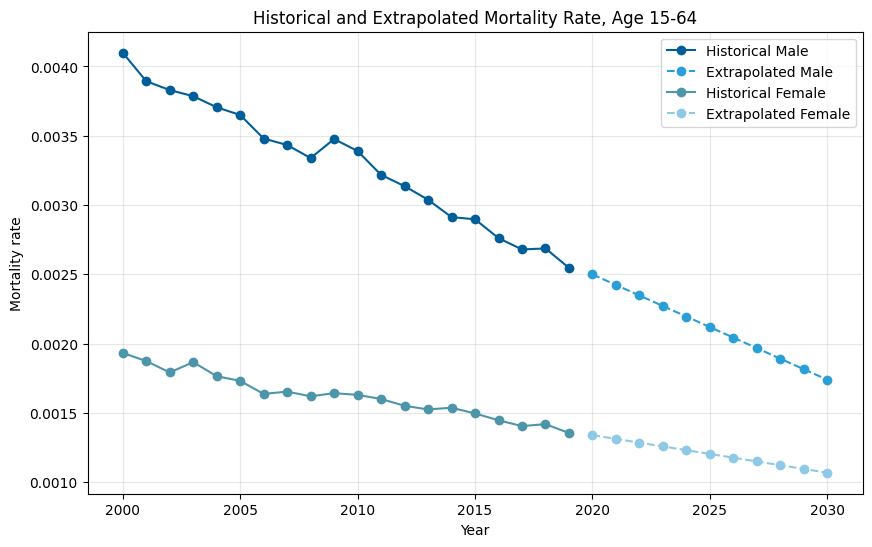

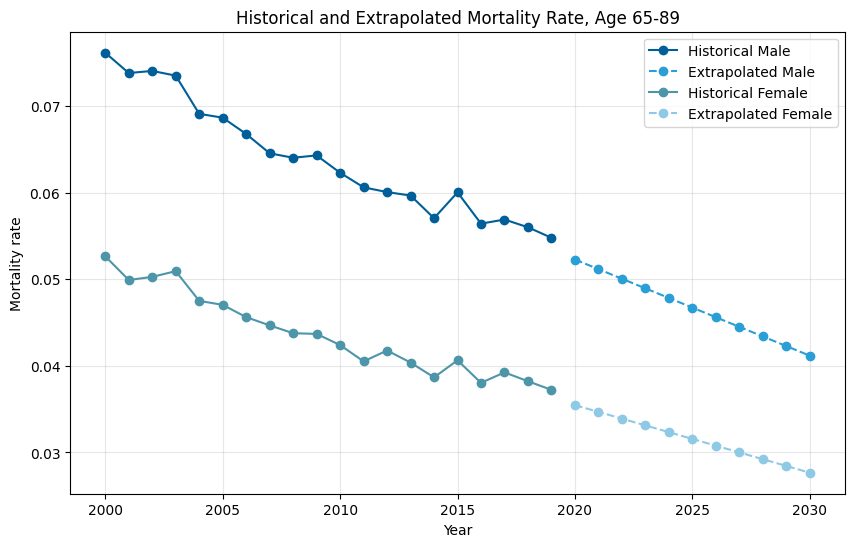

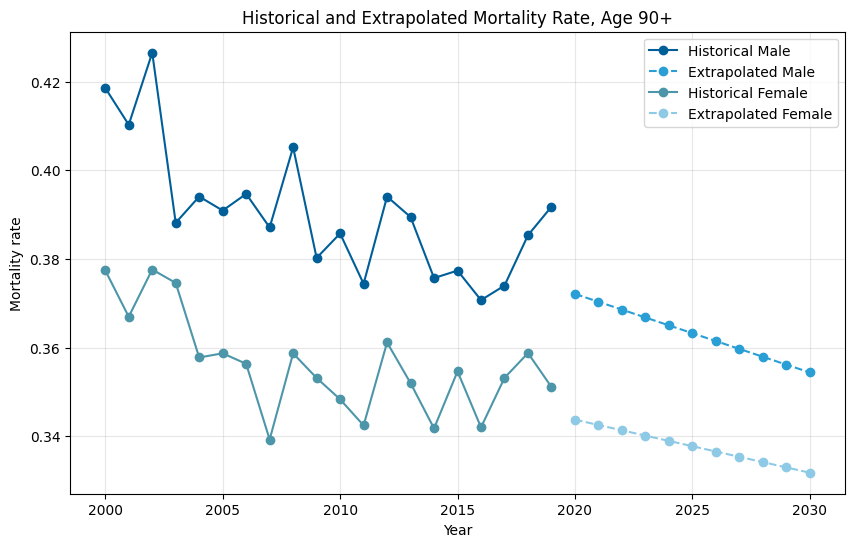

In [13]:
selected_ages = ["0", "15-64", "65-89", "90+"]

for age in selected_ages:
    plt.figure(figsize=(10, 6))

    for sex in ["Male", "Female"]:
        historical = mortality_df[
            (mortality_df["Age"] == age) &
            (mortality_df["Sex"] == sex)
        ]

        future = future_mortality_df[
            (future_mortality_df["Age"] == age) &
            (future_mortality_df["Sex"] == sex)
        ]

        color_hist = blue_dark if sex == "Male" else blue_teal
        color_future = blue_medium if sex == "Male" else blue_light

        plt.plot(
            historical["Year"],
            historical["Mortality Rate"],
            marker="o",
            color=color_hist,
            label=f"Historical {sex}"
        )

        plt.plot(
            future["Year"],
            future["Mortality Rate"],
            marker="o",
            linestyle="--",
            color=color_future,
            label=f"Extrapolated {sex}"
        )

    plt.xlabel("Year")
    plt.ylabel("Mortality rate")
    plt.title(f"Historical and Extrapolated Mortality Rate, Age {age}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [14]:
def get_year(t):
    return int(np.floor(t))

In [15]:
def get_general_params_future(t):
    year = get_year(t)

    year = max(
        params_df_extended["Year"].min(),
        min(year, params_df_extended["Year"].max())
    )

    row = params_df_extended[params_df_extended["Year"] == year].iloc[0]

    return {
        "total_fertility_rate": row["Total fertility rate"],
        "net_migration_rate": row["Net Migration Rate"],
        "p_male": row["p_male"],
        "p_female": row["p_female"]
    }

In [16]:
def get_mortality_rate_future(t, age_group, sex):
    year = get_year(t)

    year = max(
        mortality_df_extended["Year"].min(),
        min(year, mortality_df_extended["Year"].max())
    )

    row = mortality_df_extended[
        (mortality_df_extended["Year"] == year) &
        (mortality_df_extended["Age"] == age_group) &
        (mortality_df_extended["Sex"] == sex)
    ]

    return row["Mortality Rate"].values[0]

In [17]:
def population_ode_future(t, y):
    dydt = np.zeros_like(y)

    params = get_general_params_future(t)

    total_fertility_rate = params["total_fertility_rate"]
    net_migration_rate = params["net_migration_rate"]
    p_male = params["p_male"]
    p_female = params["p_female"]

    yearly_fertility_rate = total_fertility_rate / 35

    female_15_64 = y[stock_index[("15-64", "Female")]]

    total_births = yearly_fertility_rate * female_15_64
    births_by_sex = {
        "Male": p_male * total_births,
        "Female": p_female * total_births
    }

    for i, age in enumerate(age_groups):
        for sex in sexes:
            current_idx = stock_index[(age, sex)]
            current_population = y[current_idx]

            # Mortality
            mortality_rate = get_mortality_rate_future(t, age, sex)
            deaths = mortality_rate * current_population

            # Net migration
            migration = net_migration_rate * current_population

            # Births only enter the first age group
            if i == 0:
                dydt[current_idx] += births_by_sex[sex]

            # Aging in from previous age group, except for first age group
            if i > 0:
                previous_age = age_groups[i - 1]
                previous_idx = stock_index[(previous_age, sex)]

                previous_width = age_widths[previous_age]
                aging_in = y[previous_idx] / previous_width

                dydt[current_idx] += aging_in

            # Aging out to next age group, except terminal group
            if i < len(age_groups) - 1:
                current_width = age_widths[age]
                aging_out = current_population / current_width

                dydt[current_idx] -= aging_out

            # Apply migration and deaths to every stock
            dydt[current_idx] += migration
            dydt[current_idx] -= deaths

    return dydt

In [18]:
prediction_start_year = 2019
prediction_end_year = 2030

start_pop_2019 = population_df[population_df["Year"] == prediction_start_year].copy()

y0_future = []

for age, sex in stocks:
    value = start_pop_2019[
        (start_pop_2019["Age"] == age) &
        (start_pop_2019["Sex"] == sex)
    ]["Population"].values[0]

    y0_future.append(value)

y0_future = np.array(y0_future)

print(y0_future)
print("Initial 2019 total population:", y0_future.sum())

[  88007.    83392.   570621.   538855.  2979886.5 2938050.   707386.5
  891722.5   22587.5   60368. ]
Initial 2019 total population: 8880876.0


In [19]:
t_eval_future = np.arange(prediction_start_year, prediction_end_year + 1)

future_solution = solve_ivp(
    fun=population_ode_future,
    t_span=(prediction_start_year, prediction_end_year),
    y0=y0_future,
    t_eval=t_eval_future,
    method="RK45"
)

print(future_solution.success)
print(future_solution.message)

True
The solver successfully reached the end of the integration interval.


In [20]:
future_prediction_df = pd.DataFrame(
    future_solution.y.T,
    columns=[f"{age}_{sex}" for age, sex in stocks]
)

future_prediction_df["Year"] = future_solution.t.astype(int)

future_prediction_df["predicted_total_population"] = future_prediction_df[
    [f"{age}_{sex}" for age, sex in stocks]
].sum(axis=1)

future_prediction_df

,0_Male,0_Female,1-14_Male,1-14_Female,15-64_Male,15-64_Female,65-89_Male,65-89_Female,90+_Male,90+_Female,Year,predicted_total_population
0,88007.000000,83392.000000,570621.000000,538855.000000,2.979886e+06,2.938050e+06,707386.500000,891722.500000,22587.500000,60368.000000,2019,8.880876e+06
1,72580.881622,68817.195995,610149.321024,576471.517296,2.969981e+06,2.929998e+06,703847.849034,886468.453081,38872.094011,72850.546221,2020,8.930036e+06
2,67945.659215,64422.010208,639513.489289,604455.984724,2.967986e+06,2.929559e+06,703108.248133,884279.779594,50556.249931,82081.131352,2021,8.993908e+06
3,66441.983687,62994.323559,664408.547759,628192.999622,2.968479e+06,2.931347e+06,703216.176490,882991.046565,58733.493617,88702.012938,2022,9.055507e+06
4,66281.666934,62838.556797,687141.023111,649868.969062,2.971593e+06,2.935448e+06,704560.732401,882973.549886,64586.818457,93562.958528,2023,9.118855e+06
5,66387.405137,62936.636746,708544.893084,670274.939112,2.976577e+06,2.941256e+06,706321.976816,883469.864857,68774.891122,97109.321938,2024,9.181653e+06
6,66753.716499,63281.288084,728910.932757,689688.191226,2.983551e+06,2.948848e+06,708825.474363,884773.397103,71873.892993,99784.664173,2025,9.246291e+06
7,67249.692505,63748.499408,748529.371919,708384.009608,2.992521e+06,2.958215e+06,712147.586012,886958.322541,74257.385041,101880.545594,2026,9.313892e+06
8,67822.270446,64288.405608,767692.346361,726638.445940,3.003597e+06,2.969430e+06,716535.467738,890247.151301,76215.079637,103633.383633,2027,9.386100e+06
9,68411.274171,64844.076900,786435.110981,744486.021383,3.016589e+06,2.982342e+06,721773.931890,894444.449156,77887.117869,105153.128702,2028,9.462366e+06


In [21]:
flow_rows = []

for _, row in future_prediction_df.iterrows():
    year = int(row["Year"])

    # Get model parameters for this year
    params = get_general_params_future(year)

    total_fertility_rate = params["total_fertility_rate"]
    net_migration_rate = params["net_migration_rate"]

    yearly_fertility_rate = total_fertility_rate / 35

    # Female reproductive population approximation
    female_15_64 = row["15-64_Female"]

    # Births predicted by our model
    predicted_births = yearly_fertility_rate * female_15_64

    predicted_deaths = 0
    predicted_net_migration = 0

    for age in age_groups:
        for sex in sexes:
            population = row[f"{age}_{sex}"]

            mortality_rate = get_mortality_rate_future(year, age, sex)

            predicted_deaths += mortality_rate * population
            predicted_net_migration += net_migration_rate * population

    flow_rows.append({
        "Year": year,
        "Total fertility rate": total_fertility_rate,
        "Net Migration Rate": net_migration_rate,
        "Female 15-64 population": female_15_64,
        "Predicted births": predicted_births,
        "Predicted deaths": predicted_deaths,
        "Predicted net migration": predicted_net_migration
    })

model_flows_df = pd.DataFrame(flow_rows)

model_flows_df

,Year,Total fertility rate,Net Migration Rate,Female 15-64 population,Predicted births,Predicted deaths,Predicted net migration
0,2019,1.464192,0.004627,2.938050e+06,122910.551589,114205.244197,41091.813252
1,2020,1.510578,0.006745,2.929998e+06,126456.893316,119565.209718,60235.819482
2,2021,1.518425,0.006896,2.929559e+06,127094.765559,124964.573021,62017.842009
3,2022,1.526272,0.007046,2.931347e+06,127829.560607,128219.544798,63803.045996
4,2023,1.534119,0.007196,2.935448e+06,128666.496851,130097.709787,65619.339712
5,2024,1.541966,0.007346,2.941256e+06,129580.520173,130929.876627,67450.628575
6,2025,1.549813,0.007496,2.948848e+06,130576.118126,131110.275634,69314.582617
7,2026,1.557660,0.007647,2.958215e+06,131654.125681,130881.182940,71220.611848
8,2027,1.565508,0.007797,2.969430e+06,132819.021022,130444.345388,73182.877271
9,2028,1.573355,0.007947,2.982342e+06,134065.168164,129867.576110,75199.085427


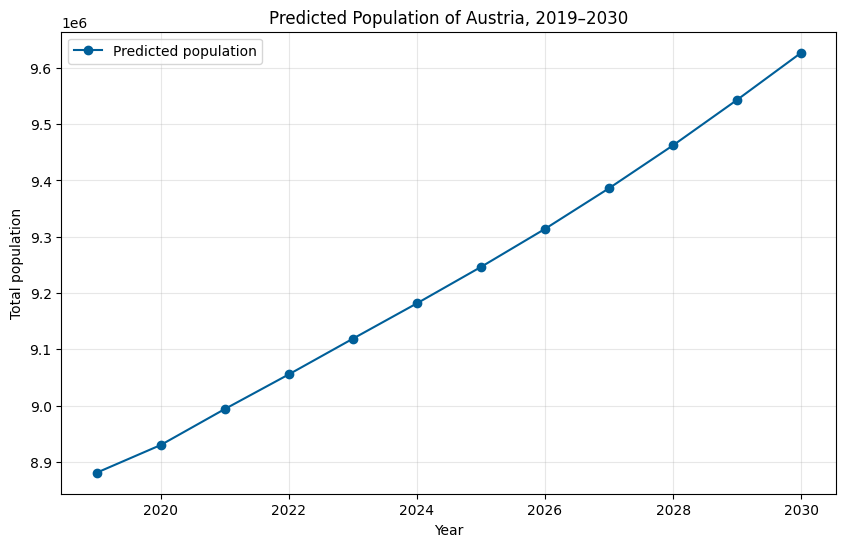

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    future_prediction_df["Year"],
    future_prediction_df["predicted_total_population"],
    marker="o",
    color=blue_dark,
    label="Predicted population"
)

plt.xlabel("Year")
plt.ylabel("Total population")
plt.title("Predicted Population of Austria, 2019–2030")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

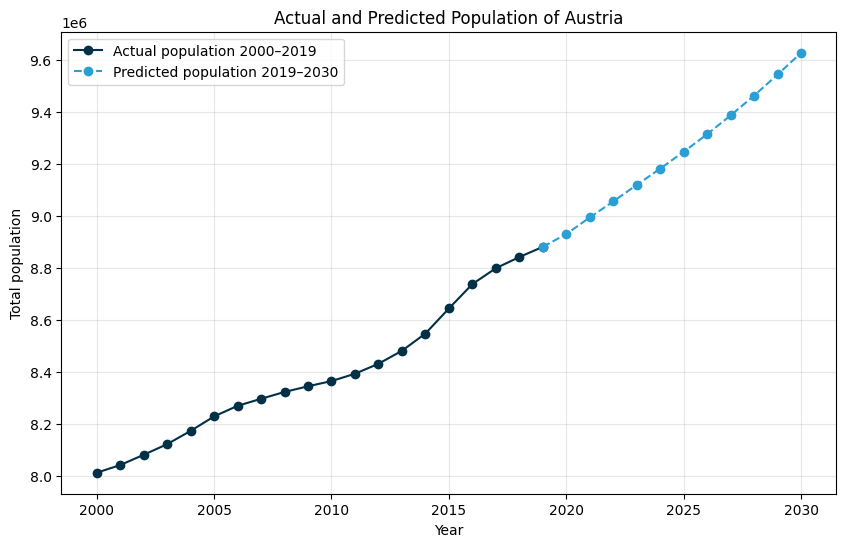

In [23]:
actual_total = (
    population_df
    .groupby("Year", as_index=False)["Population"]
    .sum()
    .rename(columns={"Population": "actual_total_population"})
)

plt.figure(figsize=(10, 6))

plt.plot(
    actual_total["Year"],
    actual_total["actual_total_population"],
    marker="o",
    color=blue_navy,
    label="Actual population 2000–2019"
)

plt.plot(
    future_prediction_df["Year"],
    future_prediction_df["predicted_total_population"],
    marker="o",
    linestyle="--",
    color=blue_medium,
    label="Predicted population 2019–2030"
)

plt.xlabel("Year")
plt.ylabel("Total population")
plt.title("Actual and Predicted Population of Austria")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
un_projection_df = pd.read_csv("../dataset/cleaned_population_dataset_2020_2030.csv")

print(un_projection_df.head())
print(un_projection_df.shape)
print(un_projection_df["Year"].unique())
print(un_projection_df["Age"].unique())
print(un_projection_df["Sex"].unique())

   Year    Age   Sex  Population
0  2020      0  Male     86581.5
1  2020   1-14  Male    573639.5
2  2020  15-64  Male   2984993.5
3  2020  65-89  Male    719610.0
4  2020    90+  Male     24256.0
(110, 4)
[2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030]
['0' '1-14' '15-64' '65-89' '90+']
['Male' 'Female']


In [25]:
un_projection_df = pd.read_csv("../dataset/cleaned_population_dataset_2020_2030.csv")

In [26]:
un_projection_total = (
    un_projection_df
    .groupby("Year", as_index=False)["Population"]
    .sum()
    .rename(columns={"Population": "un_projected_total_population"})
)

un_projection_total

,Year,un_projected_total_population
0,2020,8921405.0
1,2021,8967056.5
2,2022,9064677.0
3,2023,9130429.0
4,2024,9120813.0
5,2025,9113574.0
6,2026,9107266.0
7,2027,9101493.0
8,2028,9096265.0
9,2029,9089763.5


In [27]:
task5_comparison_df = future_prediction_df[[
    "Year",
    "predicted_total_population"
]].merge(
    un_projection_total,
    on="Year",
    how="inner"
)

task5_comparison_df["absolute_error"] = abs(
    task5_comparison_df["predicted_total_population"] -
    task5_comparison_df["un_projected_total_population"]
)

task5_comparison_df["percentage_error"] = (
    task5_comparison_df["absolute_error"] /
    task5_comparison_df["un_projected_total_population"]
) * 100

task5_comparison_df

,Year,predicted_total_population,un_projected_total_population,absolute_error,percentage_error
0,2020,8.930036e+06,8921405.0,8631.096461,0.096746
1,2021,8.993908e+06,8967056.5,26851.174163,0.299442
2,2022,9.055507e+06,9064677.0,9170.016064,0.101162
3,2023,9.118855e+06,9130429.0,11574.357754,0.126767
4,2024,9.181653e+06,9120813.0,60839.526012,0.667041
5,2025,9.246291e+06,9113574.0,132716.800808,1.456254
6,2026,9.313892e+06,9107266.0,206625.589310,2.268799
7,2027,9.386100e+06,9101493.0,284606.868723,3.127035
8,2028,9.462366e+06,9096265.0,366100.750513,4.024737
9,2029,9.543154e+06,9089763.5,453390.471718,4.987924


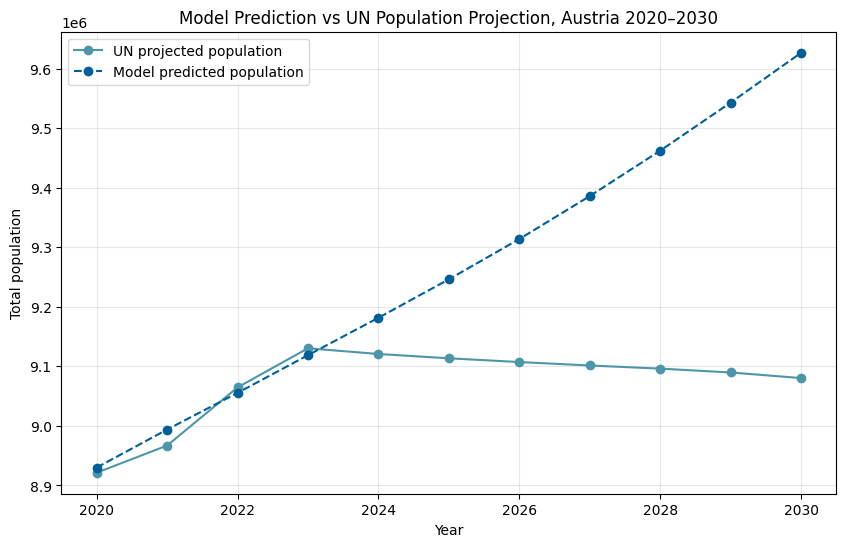

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    task5_comparison_df["Year"],
    task5_comparison_df["un_projected_total_population"],
    marker="o",
    color=blue_teal,
    label="UN projected population"
)

plt.plot(
    task5_comparison_df["Year"],
    task5_comparison_df["predicted_total_population"],
    marker="o",
    linestyle="--",
    color=blue_dark,
    label="Model predicted population"
)

plt.xlabel("Year")
plt.ylabel("Total population")
plt.title("Model Prediction vs UN Population Projection, Austria 2020–2030")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

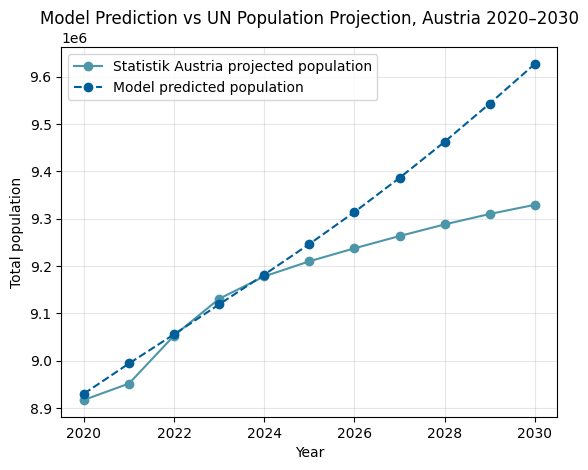

In [38]:
df_statistik_at = pd.read_csv("../dataset/statistik_at_population_2019_2030.csv")
df_statistik_at = df_statistik_at[df_statistik_at["Year"] > 2019]

plt.plot(
    df_statistik_at["Year"],
    df_statistik_at["Population"],
    marker="o",
    color=blue_teal,
    label="Statistik Austria projected population"
)

plt.plot(
    task5_comparison_df["Year"],
    task5_comparison_df["predicted_total_population"],
    marker="o",
    linestyle="--",
    color=blue_dark,
    label="Model predicted population"
)

plt.xlabel("Year")
plt.ylabel("Total population")
plt.title("Model Prediction vs UN Population Projection, Austria 2020–2030")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
comparison_year = 2030

# Model prediction by age group for selected year
model_year = future_prediction_df[
    future_prediction_df["Year"] == comparison_year
]

model_age_rows = []

for age in age_groups:
    total_age_population = 0

    for sex in sexes:
        total_age_population += model_year[f"{age}_{sex}"].values[0]

    model_age_rows.append({
        "Age": age,
        "Model population": total_age_population
    })

model_age_comparison = pd.DataFrame(model_age_rows)


# UN projection by age group for selected year
un_age_comparison = (
    un_projection_df[un_projection_df["Year"] == comparison_year]
    .groupby("Age", as_index=False)["Population"]
    .sum()
    .rename(columns={"Population": "UN projected population"})
)


# Merge model and UN
age_group_comparison_df = model_age_comparison.merge(
    un_age_comparison,
    on="Age",
    how="inner"
)

age_group_comparison_df["absolute_error"] = abs(
    age_group_comparison_df["Model population"] -
    age_group_comparison_df["UN projected population"]
)

age_group_comparison_df["percentage_error"] = (
    age_group_comparison_df["absolute_error"] /
    age_group_comparison_df["UN projected population"]
) * 100

age_group_comparison_df

,Age,Model population,UN projected population,absolute_error,percentage_error
0,0,1.361122e+05,143778.5,7666.332723,5.332044
1,1-14,1.601414e+06,1087447.0,513966.896224,47.263627
2,15-64,6.060902e+06,5665130.0,395771.834780,6.986103
3,65-89,1.639780e+06,2071346.0,431565.517322,20.835028
4,90+,1.886049e+05,112645.0,75959.929742,67.433024


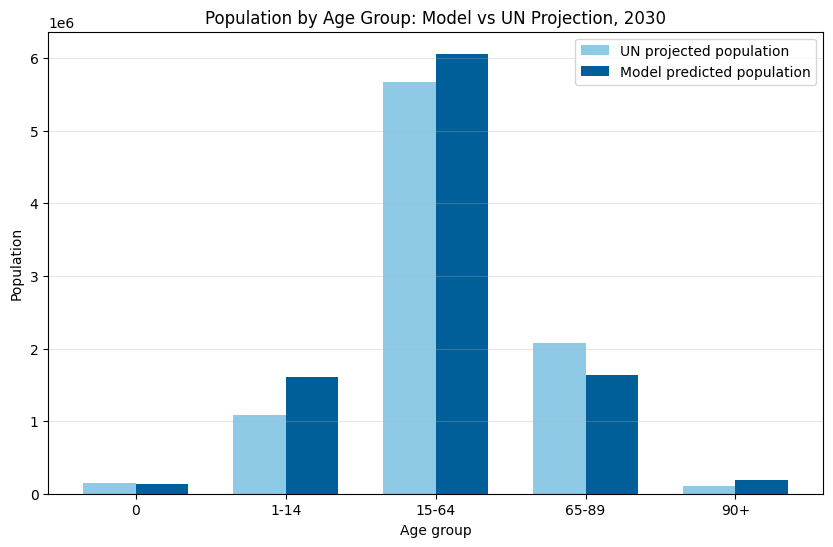

In [30]:
plt.figure(figsize=(10, 6))

x = np.arange(len(age_group_comparison_df["Age"]))
width = 0.35

plt.bar(
    x - width / 2,
    age_group_comparison_df["UN projected population"],
    width,
    color=blue_light,
    label="UN projected population"
)

plt.bar(
    x + width / 2,
    age_group_comparison_df["Model population"],
    width,
    color=blue_dark,
    label="Model predicted population"
)

plt.xlabel("Age group")
plt.ylabel("Population")
plt.title(f"Population by Age Group: Model vs UN Projection, {comparison_year}")
plt.xticks(x, age_group_comparison_df["Age"])
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

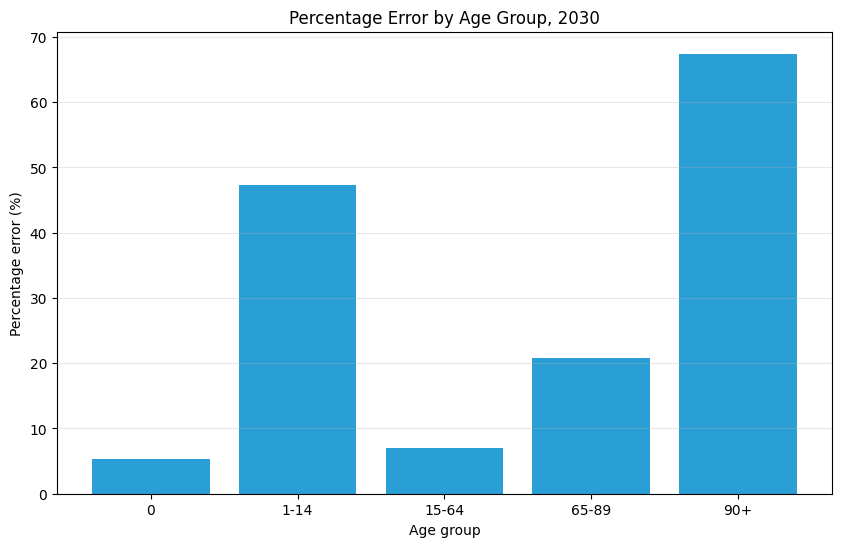

In [31]:
plt.figure(figsize=(10, 6))

plt.bar(
    age_group_comparison_df["Age"],
    age_group_comparison_df["percentage_error"],
    color=blue_medium
)

plt.xlabel("Age group")
plt.ylabel("Percentage error (%)")
plt.title(f"Percentage Error by Age Group, {comparison_year}")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [32]:
plt.figure(figsize=(10, 6))

plt.barh(
    pyramid_df["Age"],
    pyramid_df["Male"],
    color=blue_dark,
    label="Male"
)

plt.barh(
    pyramid_df["Age"],
    pyramid_df["Female"],
    color=blue_light,
    label="Female"
)

plt.xlabel("Population")
plt.ylabel("Age group")
plt.title("Predicted Population Pyramid, Austria 2030")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.show()

NameError: name 'pyramid_df' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
# Reload clean UN rates so there are no duplicated _x/_y columns
un_rates_cleaned = pd.read_csv(
    "../dataset/cleaned_un_demographic_rates_2020_2030.csv"
)

# Create UN projected total population
un_projection_total_for_rates = (
    un_projection_df
    .groupby("Year", as_index=False)["Population"]
    .sum()
    .rename(columns={"Population": "UN projected total population"})
)

# Merge once
un_rates_cleaned = un_rates_cleaned.merge(
    un_projection_total_for_rates,
    on="Year",
    how="left"
)

# Calculate UN net migration rate per 1000
un_rates_cleaned["UN net migration rate per 1000"] = (
    un_rates_cleaned["UN total net migration"] /
    un_rates_cleaned["UN projected total population"]
) * 1000

un_rates_cleaned.head()

In [ ]:
model_flows_df = model_flows_df.merge(
    future_prediction_df[["Year", "predicted_total_population"]],
    on="Year",
    how="left"
)

model_flows_df["Predicted birth rate per 1000"] = (
    model_flows_df["Predicted births"] /
    model_flows_df["predicted_total_population"]
) * 1000

model_flows_df["Predicted death rate per 1000"] = (
    model_flows_df["Predicted deaths"] /
    model_flows_df["predicted_total_population"]
) * 1000

model_flows_df["Predicted net migration rate per 1000"] = (
    model_flows_df["Predicted net migration"] /
    model_flows_df["predicted_total_population"]
) * 1000

model_flows_df.head()

In [ ]:
rates_comparison_df = model_flows_df[
    [
        "Year",
        "Predicted birth rate per 1000",
        "Predicted death rate per 1000",
        "Predicted net migration rate per 1000"
    ]
].merge(
    un_rates_cleaned[
        [
            "Year",
            "UN birth rate per 1000",
            "UN death rate per 1000",
            "UN net migration rate per 1000"
        ]
    ],
    on="Year",
    how="inner"
)

rates_comparison_df

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    rates_comparison_df["Year"],
    rates_comparison_df["Predicted birth rate per 1000"],
    marker="o",
    color=blue_dark,
    label="Model birth rate"
)

plt.plot(
    rates_comparison_df["Year"],
    rates_comparison_df["UN birth rate per 1000"],
    marker="o",
    linestyle="--",
    color=blue_light,
    label="UN birth rate"
)

plt.xlabel("Year")
plt.ylabel("Birth rate per 1000 population")
plt.title("Model vs UN Birth Rate, 2020–2030")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    rates_comparison_df["Year"],
    rates_comparison_df["Predicted death rate per 1000"],
    marker="o",
    color=blue_navy,
    label="Model death rate"
)

plt.plot(
    rates_comparison_df["Year"],
    rates_comparison_df["UN death rate per 1000"],
    marker="o",
    linestyle="--",
    color=blue_medium,
    label="UN death rate"
)

plt.xlabel("Year")
plt.ylabel("Death rate per 1000 population")
plt.title("Model vs UN Death Rate, 2020–2030")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    rates_comparison_df["Year"],
    rates_comparison_df["Predicted net migration rate per 1000"],
    marker="o",
    color=blue_dark,
    label="Model net migration rate"
)

plt.plot(
    rates_comparison_df["Year"],
    rates_comparison_df["UN net migration rate per 1000"],
    marker="o",
    linestyle="--",
    color=blue_light,
    label="UN net migration rate"
)

plt.xlabel("Year")
plt.ylabel("Net migration rate per 1000 population")
plt.title("Model vs UN Net Migration Rate, 2020–2030")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()